# Predict Customer Churn Exploration
*** 

* _Date:_ 2026-07-07
* _Competition Link:_ [Predict Customer Churn](https://www.kaggle.com/competitions/playground-series-s6e3/overview)

This notebook will be used to explore the data for the customer churn competition.

In [55]:
# import libraries

import pandas as pd 
import polars as pl 
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)

## Read data

In [56]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

## Exploration

Goal is to understand the features before modeling the data

In [57]:
print(f"Train Shape: {train.shape[0]:,} | Test Shape: {test.shape[0]:,}")

Train Shape: 594,194 | Test Shape: 254,655


In [58]:
train.head(3)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35,No


In [59]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  str    
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  str    
 4   Dependents        594194 non-null  str    
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  str    
 7   MultipleLines     594194 non-null  str    
 8   InternetService   594194 non-null  str    
 9   OnlineSecurity    594194 non-null  str    
 10  OnlineBackup      594194 non-null  str    
 11  DeviceProtection  594194 non-null  str    
 12  TechSupport       594194 non-null  str    
 13  StreamingTV       594194 non-null  str    
 14  StreamingMovies   594194 non-null  str    
 15  Contract          594194 non-null  str    
 16  PaperlessBilling  594194 non-nu

### Numeric feature distributions

* `SeniorCitizen`: is a OHE value that is imbalanced
* Other features need to be transformed to better approximate a normal distribution

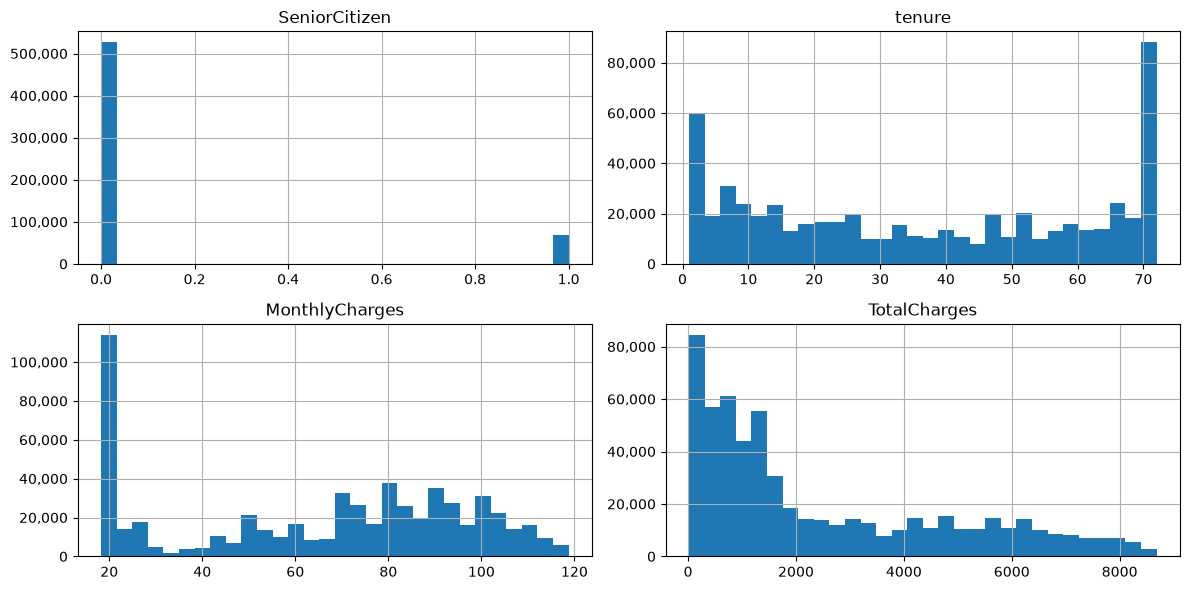

In [60]:
from matplotlib.ticker import StrMethodFormatter

numeric_cols = train.select_dtypes(include="number").columns.drop("id")

axes = train[numeric_cols].hist(figsize=(12, 6), bins=30)
for ax in axes.flat:
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.show()

### Missing values

No  missing data (as shown earlier), but could be missing text labels. will need to look at the distinct values.

In [61]:
null_pct = (train.isna().mean() * 100).round(2).sort_values(ascending=False)
null_pct.to_frame("percent_null")

,percent_null
id,0.0
gender,0.0
SeniorCitizen,0.0
Partner,0.0
Dependents,0.0
tenure,0.0
PhoneService,0.0
MultipleLines,0.0
InternetService,0.0
OnlineSecurity,0.0


In [62]:
train.nunique()

id                  594194
gender                   2
SeniorCitizen            2
Partner                  2
Dependents               2
tenure                  72
PhoneService             2
MultipleLines            3
InternetService          3
OnlineSecurity           3
OnlineBackup             3
DeviceProtection         3
TechSupport              3
StreamingTV              3
StreamingMovies          3
Contract                 3
PaperlessBilling         2
PaymentMethod            4
MonthlyCharges        1921
TotalCharges         31910
Churn                    2
dtype: int64

Quick note: Many of the features below are imbalanced.

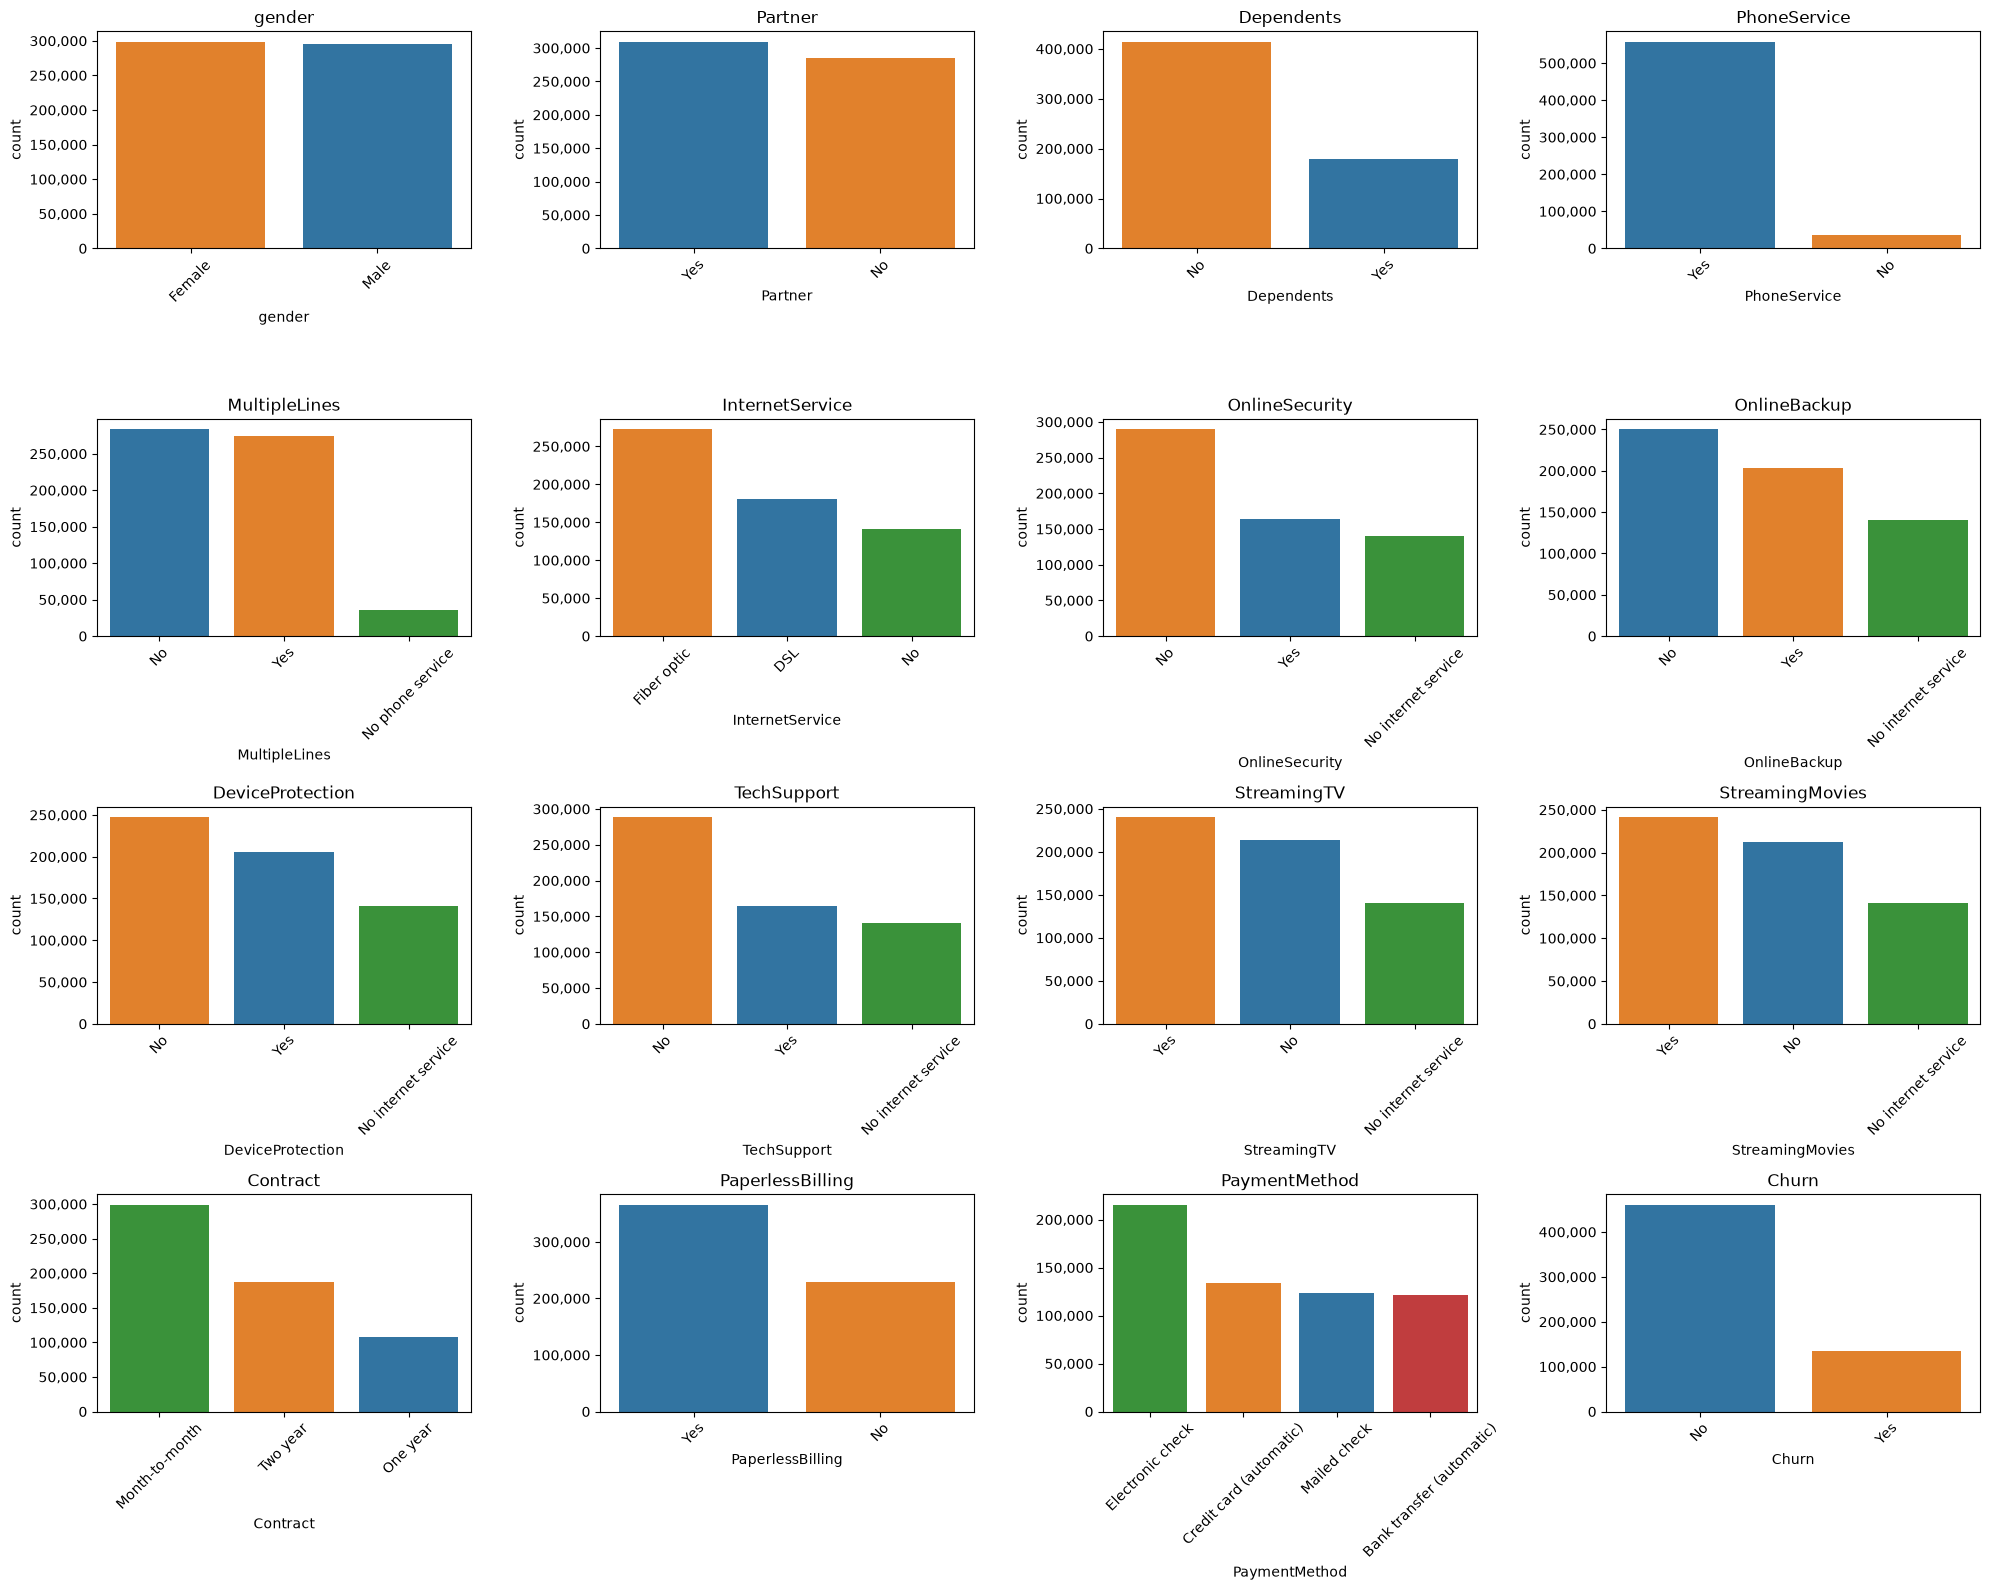

In [63]:
categorical_cols = train.select_dtypes(exclude="number")

fig, axes = plt.subplots(4, 4, figsize=(20, 16))

for ax, col in zip(axes.flat, categorical_cols):
    order = train[col].value_counts().index
    sns.countplot(data=train, x=col, order=order, hue=col, legend=False, palette="tab10", ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

plt.tight_layout()
plt.show()

## Churn Rate by Category

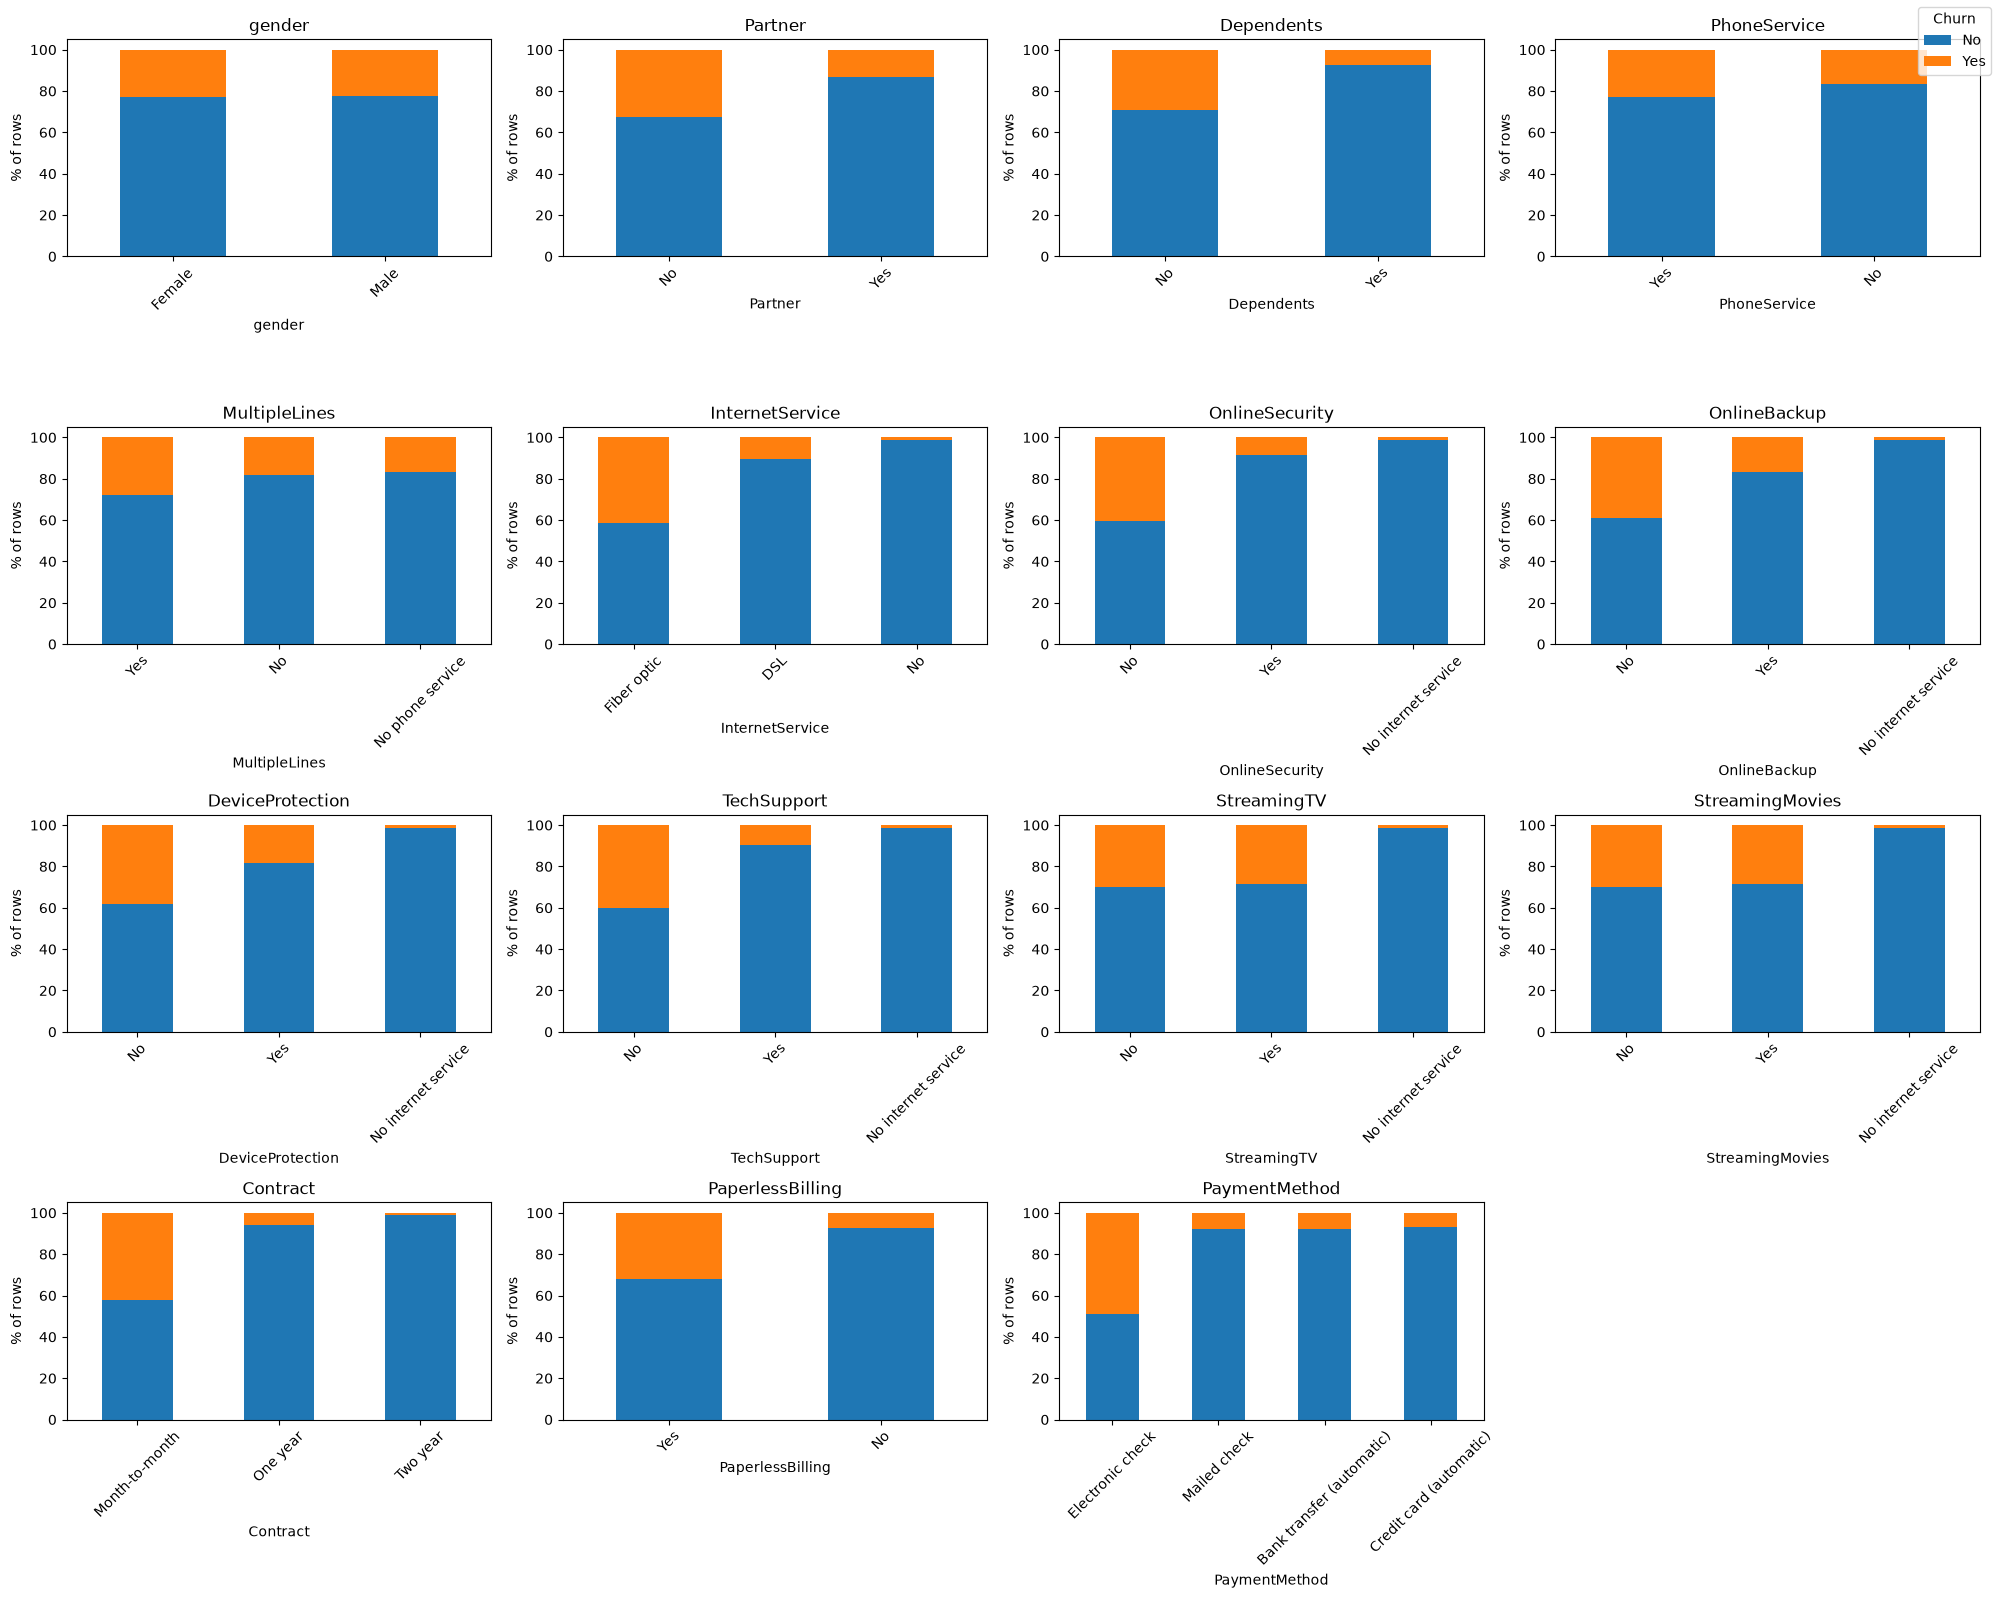

In [ ]:
cols_to_plot = [c for c in categorical_cols if c != "Churn"]

fig, axes = plt.subplots(4, 4, figsize=(20, 16))

for ax, col in zip(axes.flat, cols_to_plot):
    churn_rate = pd.crosstab(train[col], train["Churn"], normalize="index") * 100
    churn_rate = churn_rate.sort_values("Yes", ascending=False)
    churn_rate.plot(kind="bar", stacked=True, ax=ax, legend=False)
    ax.set_title(col)
    ax.set_ylabel("% of rows")
    ax.tick_params(axis="x", rotation=45)
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

for ax in axes.flat[len(cols_to_plot):]:
    ax.axis("off")

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Churn", loc="upper right")
plt.tight_layout()
plt.show()

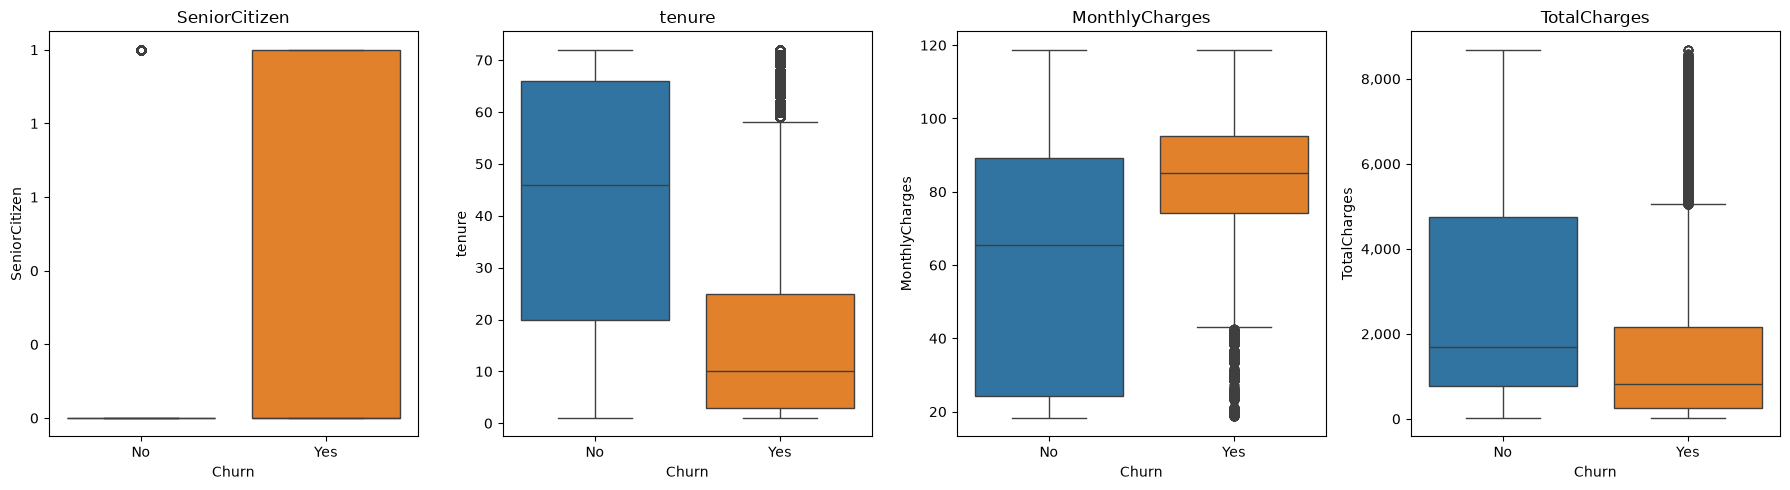

In [66]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 5))

for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(data=train, x="Churn", y=col, hue="Churn", legend=False, palette="tab10", ax=ax)
    ax.set_title(col)
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

plt.tight_layout()
plt.show()

## Data Quality Checks

In [67]:
print(f"Duplicate rows: {train.duplicated().sum():,}")

Duplicate rows: 0


In [68]:
phone_mismatch = train[(train["PhoneService"] == "No") & (train["MultipleLines"] != "No phone service")]
print(f"PhoneService/MultipleLines mismatches: {len(phone_mismatch):,}")

internet_addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
for col in internet_addon_cols:
    mismatch = train[(train["InternetService"] == "No") & (train[col] != "No internet service")]
    print(f"InternetService/{col} mismatches: {len(mismatch):,}")

PhoneService/MultipleLines mismatches: 0
InternetService/OnlineSecurity mismatches: 0
InternetService/OnlineBackup mismatches: 0
InternetService/DeviceProtection mismatches: 0
InternetService/TechSupport mismatches: 0
InternetService/StreamingTV mismatches: 0
InternetService/StreamingMovies mismatches: 0


count    594194.000000
mean        -11.409798
std         298.747588
min       -7369.250000
25%         -70.550000
50%           0.000000
75%          60.250000
max        7308.300000
dtype: float64


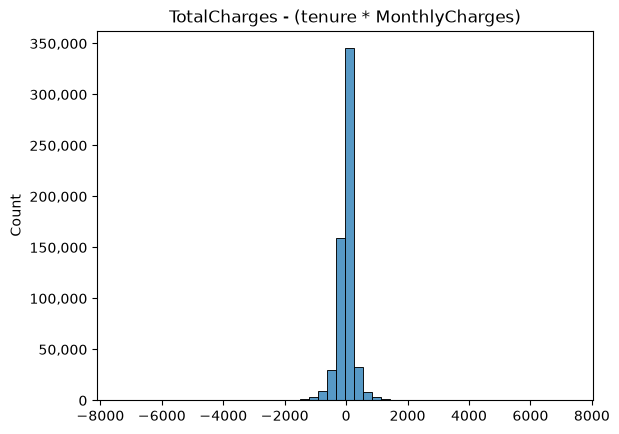

In [69]:
expected_total = train["tenure"] * train["MonthlyCharges"]
residual = train["TotalCharges"] - expected_total

print(residual.describe())

sns.histplot(residual, bins=50)
plt.title("TotalCharges - (tenure * MonthlyCharges)")
plt.gca().yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
plt.show()

## Correlation Heatmap

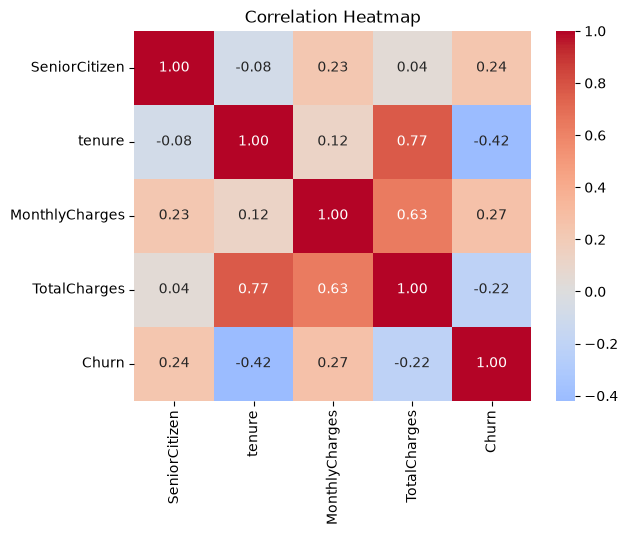

In [70]:
corr_df = train[numeric_cols].copy()
corr_df["Churn"] = train["Churn"].map({"No": 0, "Yes": 1})

sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## Train vs Test Distribution Comparison

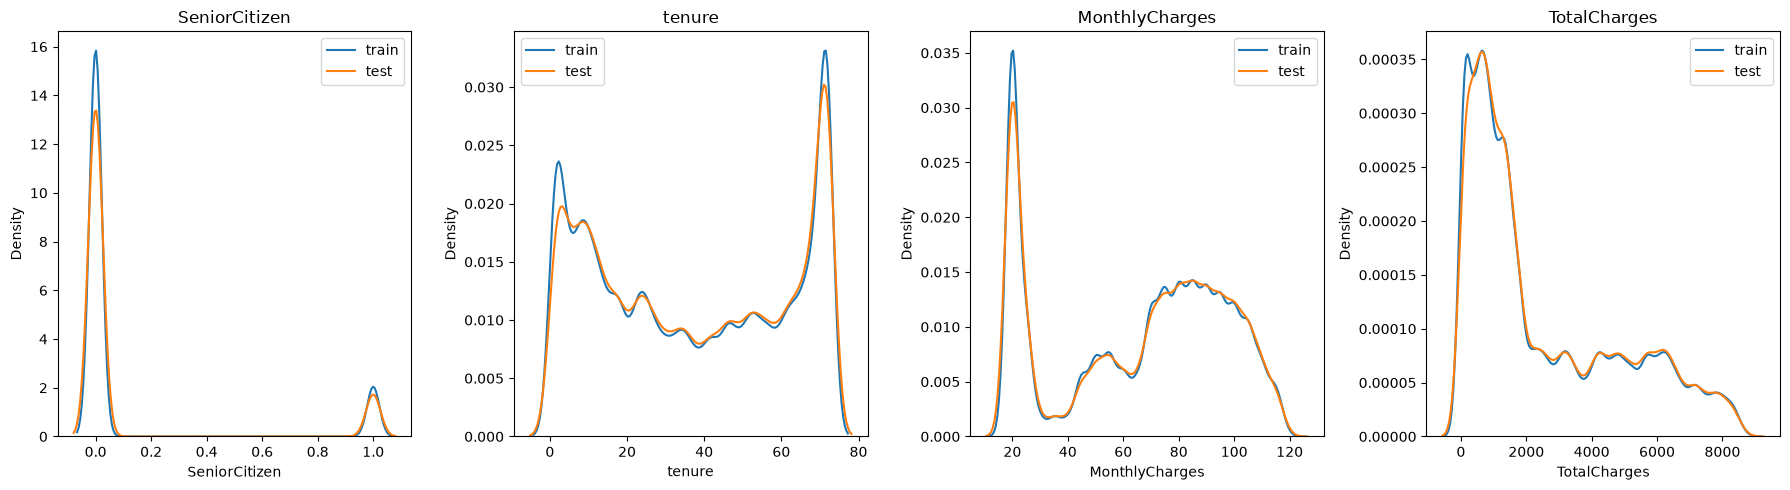

In [71]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 5))

for ax, col in zip(axes.flat, numeric_cols):
    sns.kdeplot(train[col], label="train", ax=ax)
    sns.kdeplot(test[col], label="test", ax=ax)
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

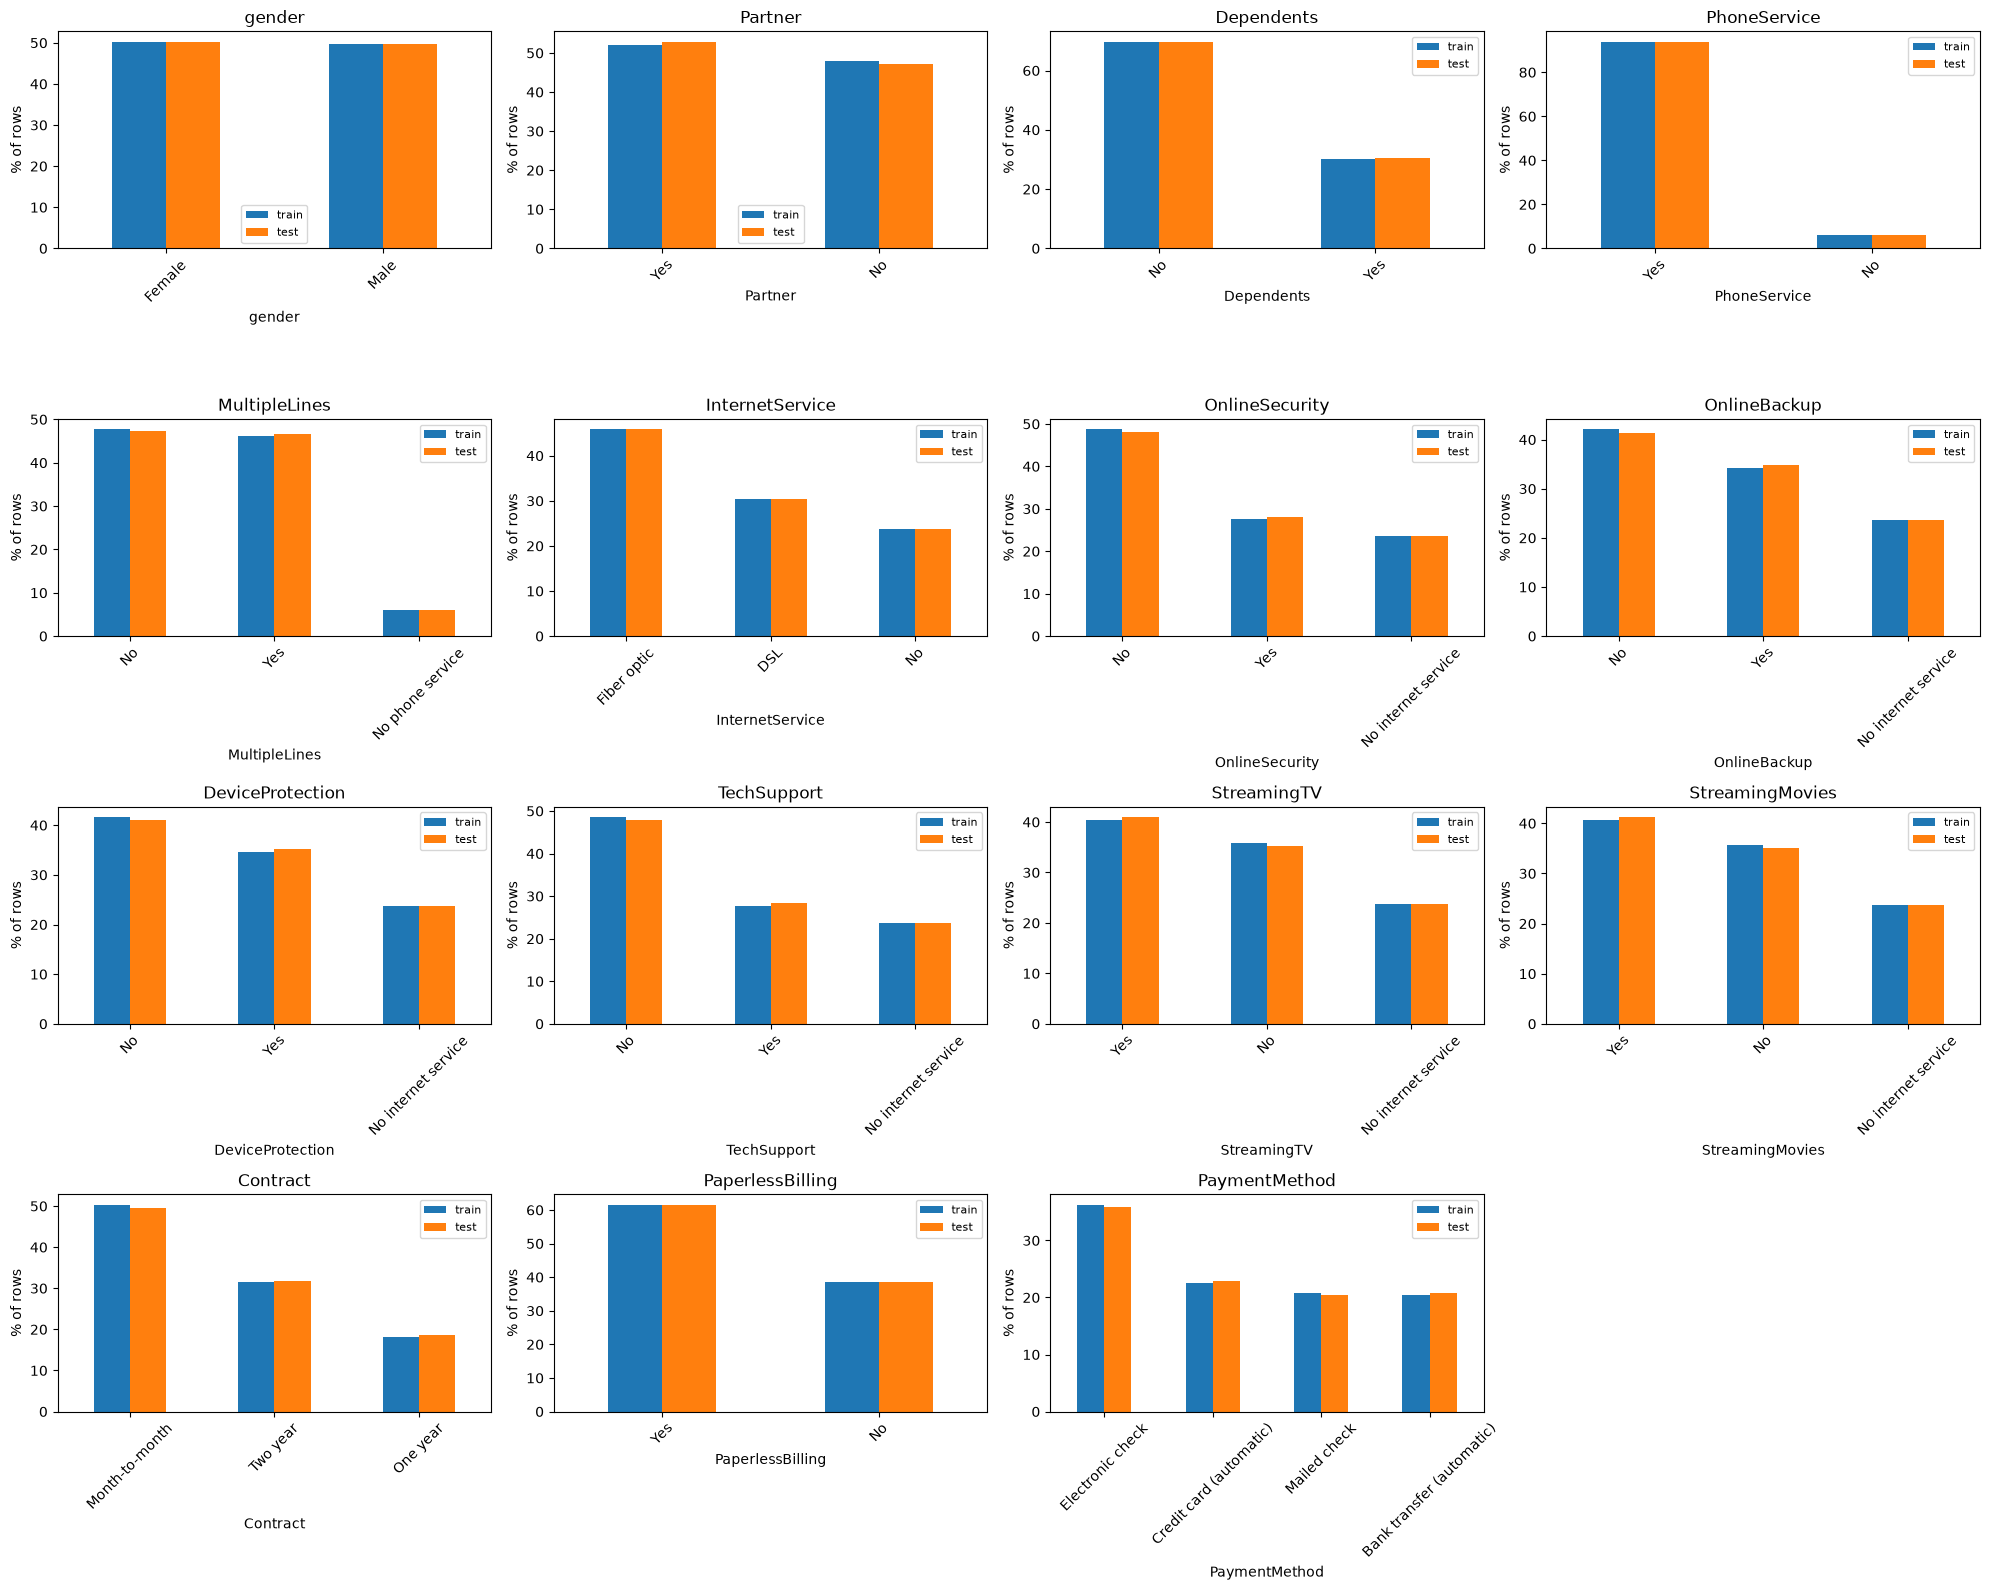

In [72]:
cols_to_plot = [c for c in categorical_cols if c != "Churn"]

fig, axes = plt.subplots(4, 4, figsize=(20, 16))

for ax, col in zip(axes.flat, cols_to_plot):
    train_pct = train[col].value_counts(normalize=True).rename("train")
    test_pct = test[col].value_counts(normalize=True).rename("test")
    compare = pd.concat([train_pct, test_pct], axis=1) * 100
    compare.plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.set_ylabel("% of rows")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)

for ax in axes.flat[len(cols_to_plot):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Next Steps:

* Separate features & target variables
* Run a baseline model
* Think through any additional features that could be additive (hint: new customers vs. those with long tenures)